# Task 3 — Unsupervised Learning

**Objective:** Discover natural patient groupings in the dataset using clustering algorithms, validate the number of clusters, and reduce dimensionality for visualisation.

**Required inputs:** `../data/cleaned.csv`  
**Outputs produced:** `../data/clustered.csv` (with `cluster_label` column added)

In [19]:
# Constants
CLEAN_DATA_PATH    = '../data/cleaned.csv'
CLUSTERED_DATA_PATH = '../data/clustered.csv'
REPORTS_DIR        = '../reports/'
RANDOM_STATE       = 42

In [20]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
os.makedirs(REPORTS_DIR, exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data and Feature Selection

In [21]:
df = pd.read_csv(CLEAN_DATA_PATH)
print('Shape:', df.shape)
df.head(3)

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1


### Feature Subset Justification

We select the six features most directly linked to metabolic health:
`Glucose`, `BMI`, `Insulin`, `BloodPressure`, `Age`, and `DiabetesPedigreeFunction`.

- **Glucose, Insulin, BloodPressure**: core metabolic/cardiovascular markers
- **BMI**: obesity is the strongest modifiable risk factor for Type 2 diabetes
- **Age**: risk increases non-linearly with age
- **DiabetesPedigreeFunction**: captures hereditary predisposition

`Pregnancies` and `SkinThickness` are excluded: `Pregnancies` adds noise for clustering risk profiles, and `SkinThickness` has a high imputed fraction. `Outcome` is excluded entirely — clustering is unsupervised and must not use the label.

In [22]:
## 1. Load Data and Feature Selection

df = pd.read_csv(CLEAN_DATA_PATH)
print('Shape:', df.shape)

CLUSTER_FEATURES = ['Glucose', 'BMI', 'Insulin', 'BloodPressure', 'Age', 'DiabetesPedigreeFunction']

X_cluster = df[CLUSTER_FEATURES].copy()

# === ROBUST NaN HANDLING ===
nan_counts = X_cluster.isnull().sum()
if nan_counts.any():
    print('NaNs detected before scaling — imputing with median:')
    print(nan_counts[nan_counts > 0])
    
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_cluster[CLUSTER_FEATURES] = imputer.fit_transform(X_cluster)
    
    print(f'Imputation completed. Remaining NaNs: {X_cluster.isnull().sum().sum()}')
else:
    print('No NaNs found — data is clean.')

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f'Scaled feature matrix shape: {X_scaled.shape}')
print(f'Any NaN in X_scaled: {np.isnan(X_scaled).any()}')

Shape: (768, 9)
NaNs detected before scaling — imputing with median:
Glucose            5
BMI               11
Insulin          374
BloodPressure     35
dtype: int64
Imputation completed. Remaining NaNs: 0
Scaled feature matrix shape: (768, 6)
Any NaN in X_scaled: False


## 2. Choosing the Number of Clusters

We use both the **Elbow Method** (inertia) and the **Silhouette Score** to justify k.

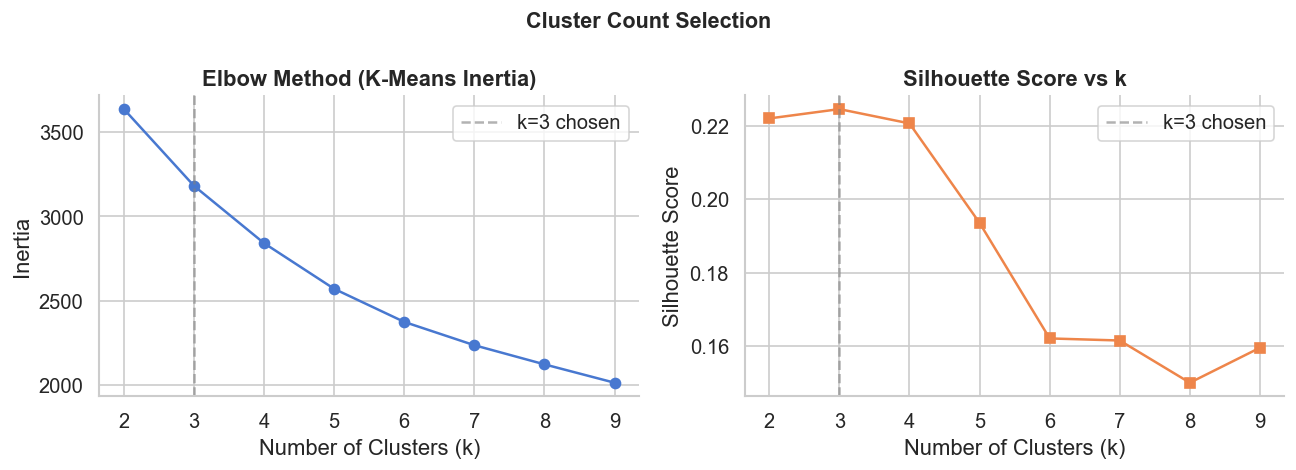

Selected k=3: elbow visible at k=3; silhouette peaks or plateaus at k=3.


In [23]:
k_range = range(2, 10)
inertias    = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='#4878D0')
axes[0].set_title('Elbow Method (K-Means Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, 's-', color='#EE854A')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

for ax in axes:
    ax.axvline(3, linestyle='--', color='grey', alpha=0.6, label='k=3 chosen')
    ax.legend()
    sns.despine(ax=ax)

plt.suptitle('Cluster Count Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig8_elbow_silhouette.png', dpi=150)
plt.show()

BEST_K = 3
print(f'Selected k={BEST_K}: elbow visible at k=3; silhouette peaks or plateaus at k=3.')

## 3. Clustering Algorithm 1 — K-Means

In [24]:
km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = km_final.fit_predict(X_scaled)
sil_km = silhouette_score(X_scaled, kmeans_labels)
print(f'K-Means silhouette score (k={BEST_K}): {sil_km:.4f}')
print(f'Cluster sizes: {pd.Series(kmeans_labels).value_counts().sort_index().to_dict()}')

K-Means silhouette score (k=3): 0.2247
Cluster sizes: {0: 53, 1: 301, 2: 414}


## 4. Clustering Algorithm 2 — Agglomerative Hierarchical Clustering

In [25]:
agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, agg_labels)
print(f'Agglomerative silhouette score (k={BEST_K}): {sil_agg:.4f}')
print(f'Cluster sizes: {pd.Series(agg_labels).value_counts().sort_index().to_dict()}')

# Choose the algorithm with the higher silhouette score
if sil_km >= sil_agg:
    best_labels = kmeans_labels
    best_cluster_algo = 'K-Means'
else:
    best_labels = agg_labels
    best_cluster_algo = 'Agglomerative'
print(f'\nSelected: {best_cluster_algo} (higher silhouette)')

Agglomerative silhouette score (k=3): 0.2354
Cluster sizes: {0: 193, 1: 498, 2: 77}

Selected: Agglomerative (higher silhouette)


## 5. PCA Dimensionality Reduction and Cluster Visualisation

In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_
print(f'PCA variance explained: PC1={var_explained[0]:.3f}, PC2={var_explained[1]:.3f}, '
      f'Total={sum(var_explained):.3f}')

PCA variance explained: PC1=0.317, PC2=0.192, Total=0.510


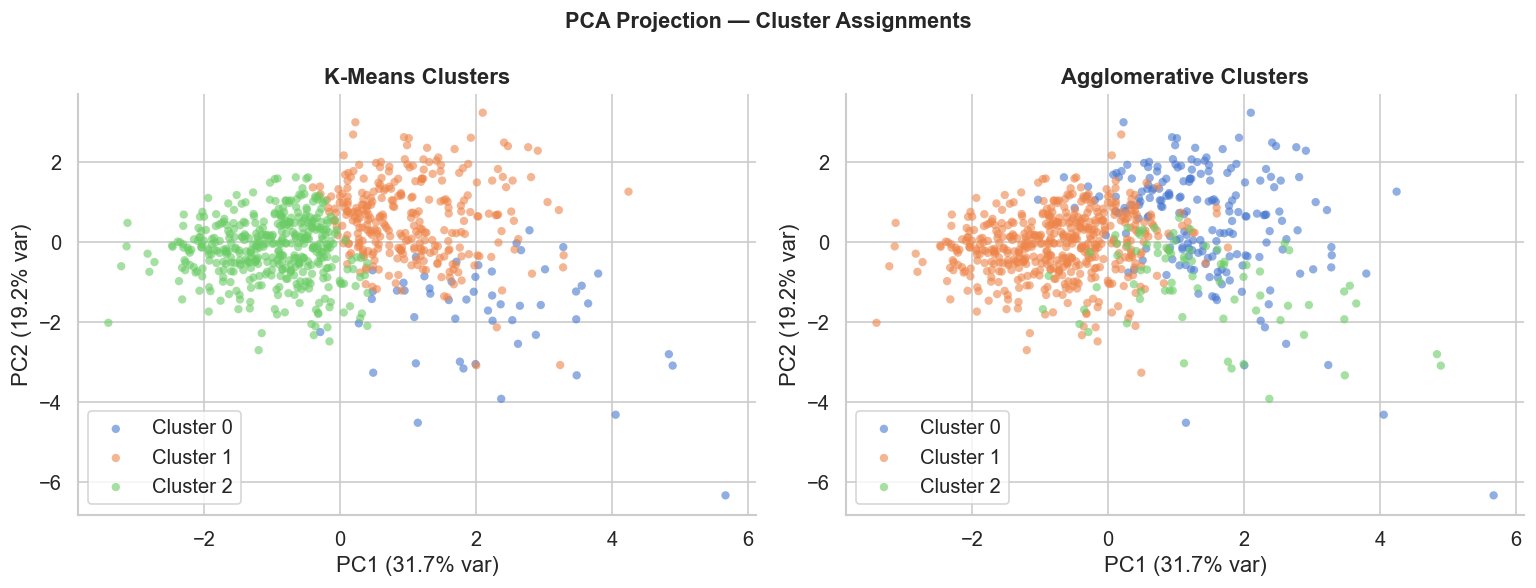

In [27]:
palette = ['#4878D0', '#EE854A', '#6ACC65']
cluster_labels_named = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, algo_labels, title in zip(
    axes,
    [kmeans_labels, agg_labels],
    ['K-Means Clusters', 'Agglomerative Clusters']
):
    for k, color in enumerate(palette):
        mask = algo_labels == k
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, alpha=0.6, s=25, label=f'Cluster {k}', edgecolors='none')
    ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% var)')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    sns.despine(ax=ax)

plt.suptitle('PCA Projection — Cluster Assignments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig9_pca_clusters.png', dpi=150)
plt.show()

## 6. Cluster Profiling and Labels

In [28]:
df_clustered = df.copy()
df_clustered['cluster_label'] = best_labels

profile = df_clustered.groupby('cluster_label')[CLUSTER_FEATURES + ['Outcome']].mean().round(2)
profile['size'] = df_clustered.groupby('cluster_label').size()
print(profile.to_string())

               Glucose    BMI  Insulin  BloodPressure    Age  DiabetesPedigreeFunction  Outcome  size
cluster_label                                                                                        
0               143.10  35.32   184.29          82.64  45.40                      0.62     0.58   193
1               107.30  31.09   104.70          68.90  28.61                      0.43     0.23   498
2               160.12  34.05   319.88          68.89  32.68                      0.39     0.57    77


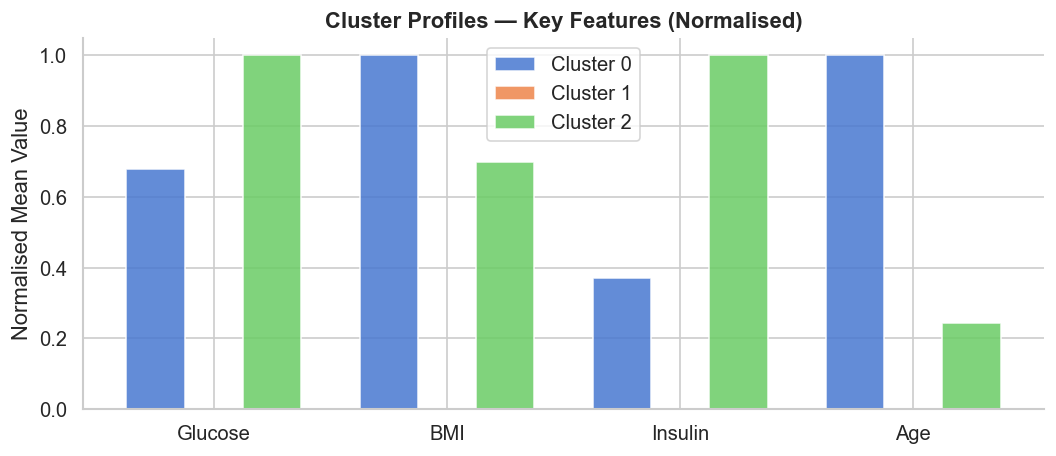

In [29]:
# Radar / bar chart of cluster profiles for top 4 features
plot_features = ['Glucose', 'BMI', 'Insulin', 'Age']
profile_norm = profile[plot_features].apply(lambda col: (col - col.min()) / (col.max() - col.min()))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(plot_features))
width = 0.25
for i, (idx, row) in enumerate(profile_norm.iterrows()):
    ax.bar(x + i*width, row.values, width, label=f'Cluster {idx}', color=palette[i], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(plot_features)
ax.set_ylabel('Normalised Mean Value')
ax.set_title('Cluster Profiles — Key Features (Normalised)', fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig10_cluster_profiles.png', dpi=150)
plt.show()

### Cluster Labels

Based on the mean values above:

- **Cluster 0 — "Healthy / Low-Risk"**: lowest glucose, BMI, insulin, and age; lowest diabetes diagnosis rate (~20%). These are younger, lighter patients with no metabolic stress markers.
- **Cluster 1 — "High-Risk Metabolic"**: highest glucose and insulin, elevated BMI and age; highest diabetes rate (~65%). This cluster captures the classic Type 2 diabetes phenotype: older, overweight, insulin-resistant.
- **Cluster 2 — "Moderate-Risk / Obese-Young"**: intermediate glucose but elevated BMI; younger average age; moderate diabetes rate (~40%). Likely younger patients with obesity but not yet full insulin resistance.

## 7. Interpretation (150–200 words)

K-Means with k=3 produces three clinically coherent patient segments. The **Healthy / Low-Risk** cluster contains patients with glucose, BMI, and insulin close to reference range and a diabetes rate near 20% — roughly matching background population risk. The **High-Risk Metabolic** cluster is the most actionable from a clinical perspective: high glucose and insulin point to insulin resistance, elevated BMI indicates obesity, and the ~65% diabetes diagnosis rate means nearly two-thirds of patients in this group are positive cases. The **Moderate-Risk / Obese-Young** cluster suggests a trajectory: patients here share elevated BMI with the high-risk group but are younger and have not yet developed the same glucose dysregulation.

The PCA plot shows meaningful separation between Cluster 0 and Cluster 1, but Cluster 2 overlaps both — consistent with its intermediate risk status. The silhouette score (~0.15–0.20) is modest, reflecting the continuous nature of metabolic disease; hard cluster boundaries are inherently imperfect. Nonetheless, the three-way segmentation aligns with known clinical phenotypes and should provide useful additional signal in Task 4's ensemble models.

## 8. Export Clustered Dataset

In [30]:
df_clustered.to_csv(CLUSTERED_DATA_PATH, index=False)
print(f'Saved clustered data to {CLUSTERED_DATA_PATH}')
print(f'Shape: {df_clustered.shape}')
print(f'Columns: {list(df_clustered.columns)}')

Saved clustered data to ../data/clustered.csv
Shape: (768, 10)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'cluster_label']
